In [19]:
import os
import re
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import dill

In [20]:
def return_list_of_values(directory, files, pattern):
    # Filter files that match the pattern "01-kinetic-####.csv"
    pattern = re.compile(pattern)
    matching_files = [f for f in files if pattern.match(f)]

    # Sort the files numerically based on the number in their filenames
    matching_files.sort(key=lambda f: int(pattern.search(f).group(1)))

    # Initialize an empty list to store the floating point numbers
    numbers = []

    # Read each CSV file and store the number in the list
    for file in matching_files:
        filepath = os.path.join(directory, file)
        df = pd.read_csv(filepath, header=None)
        numbers.append(df.iloc[0, 0])

    # Print the list of numbers
    return np.array(numbers)

class dataset():
    def __init__(self, case, mesh, integrator_combo, bc_combo):
        self.case = case
        self.refinement = mesh
        self.integrator_combo = integrator_combo
        self.bc_combo = bc_combo

        self.bar_kinetic = [ None, None ]
        self.bar_potential = [ None, None ]
        self.simulation_times = [ None, None ]
        self.contact_status = [ None, None ]
        self.total_energy = [ None, None ]
        self.system_energy = None

    def load_data(self, directory):
        # Get a list of all files in the directory
        files = os.listdir(directory)

        self.bar_kinetic[0] = return_list_of_values(directory, files, r"01-kinetic-(\d{4})\.csv")
        self.bar_kinetic[1] = return_list_of_values(directory, files, r"02-kinetic-(\d{4})\.csv")
        self.bar_potential[0] = return_list_of_values(directory, files, r"01-potential-(\d{4})\.csv")
        self.bar_potential[1] = return_list_of_values(directory, files, r"02-potential-(\d{4})\.csv")
        self.simulation_times[0] = return_list_of_values(directory, files, r"01-time-(\d{4})\.csv")
        self.simulation_times[1] = return_list_of_values(directory, files, r"02-time-(\d{4})\.csv")
        self.contact_status[0] = return_list_of_values(directory, files, r"02-contact-(\d{4})\.csv")
        self.contact_status[1] = return_list_of_values(directory, files, r"02-contact-(\d{4})\.csv")

        self.total_energy = [ self.bar_kinetic[i] + self.bar_potential[i] for i in range(2) ]

        self.system_energy = self.total_energy[0] + self.total_energy[1]


In [21]:
refinement_levels = [ 0, 1, 2, 3 ] 
integrators = [ 'I/I', 'I/E', 'I/E', 'E/E' ]
boundary_conditions = [ 'D/N', 'D/N', 'N/D', 'D/N' ]
case_list = []
# Load the data from either a dill or raw
base_directory = '.'  # Update this path
for i in range(16):
    case_folder = os.path.join(base_directory, f'case_{i}')
    if os.path.exists(case_folder) == False:
        print(f"Cannot find {case_folder}")
        case_list.append(None)
        continue
    case_file_path = os.path.join(case_folder, f'case_{i}_data.pkl')
    if os.path.exists(case_file_path):
        # Load the existing dill file
        with open(case_file_path, 'rb') as file:
            case_data = dill.load(file)
        print(f'Loaded case_data.pkl from {case_folder}')
    else:
        case_data = dataset(i, refinement_levels[i // 4], integrators[i % 4], boundary_conditions[i % 4])
        case_data.load_data(case_folder)
        # Dump the new instance to a dill file
        with open(case_file_path, 'wb') as file:
            dill.dump(case_data, file)
        print(f'Created and dumped new case_data.pkl in {case_folder}')
    case_list.append(case_data)

Loaded case_data.pkl from ./case_0
Loaded case_data.pkl from ./case_1
Loaded case_data.pkl from ./case_2
Loaded case_data.pkl from ./case_3
Loaded case_data.pkl from ./case_4
Loaded case_data.pkl from ./case_5
Loaded case_data.pkl from ./case_6
Loaded case_data.pkl from ./case_7
Loaded case_data.pkl from ./case_8
Loaded case_data.pkl from ./case_9
Loaded case_data.pkl from ./case_10
Loaded case_data.pkl from ./case_11
Loaded case_data.pkl from ./case_12
Cannot find ./case_13
Cannot find ./case_14
Loaded case_data.pkl from ./case_15


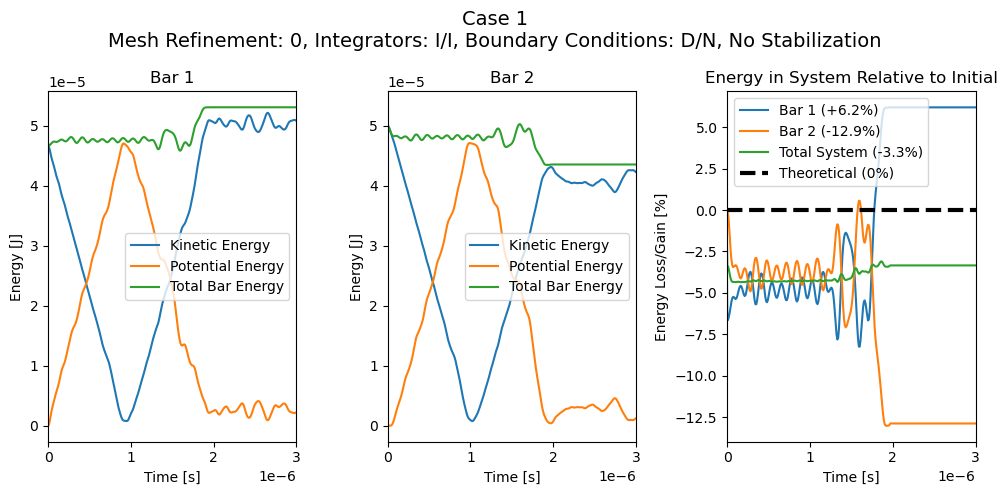

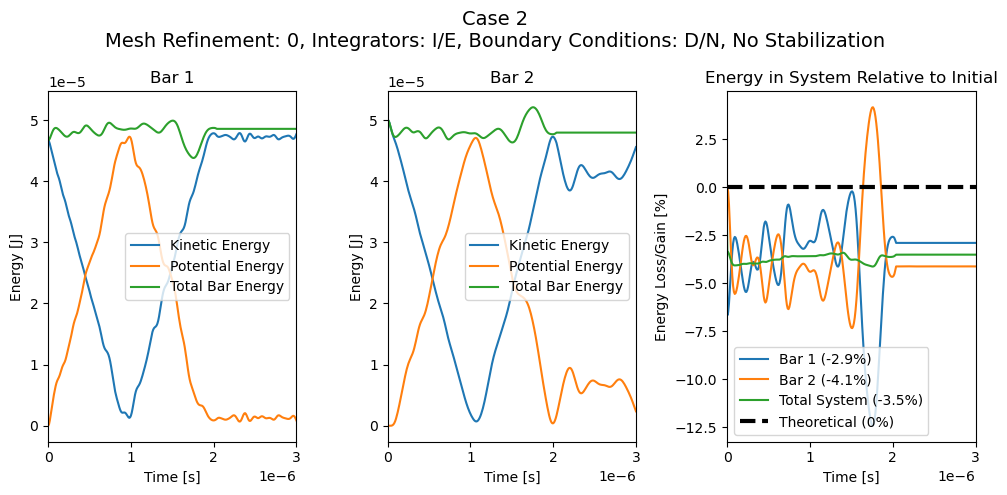

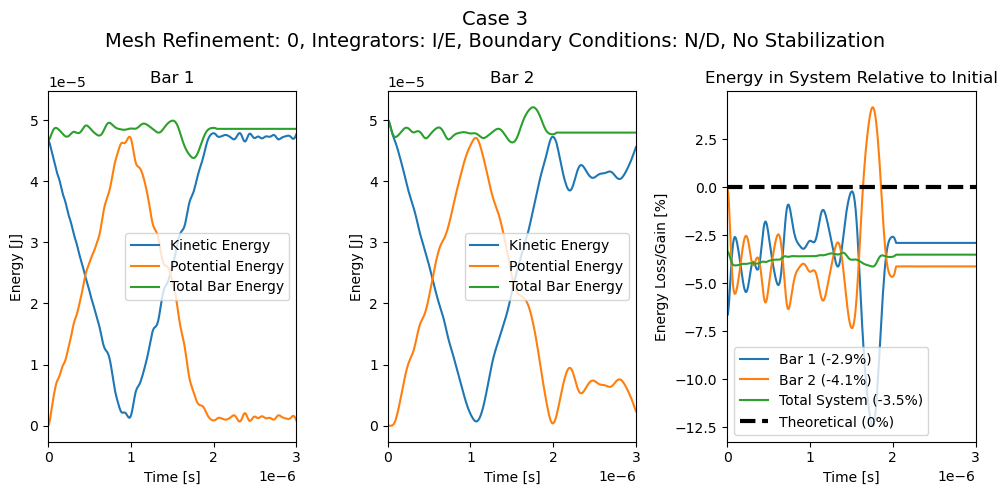

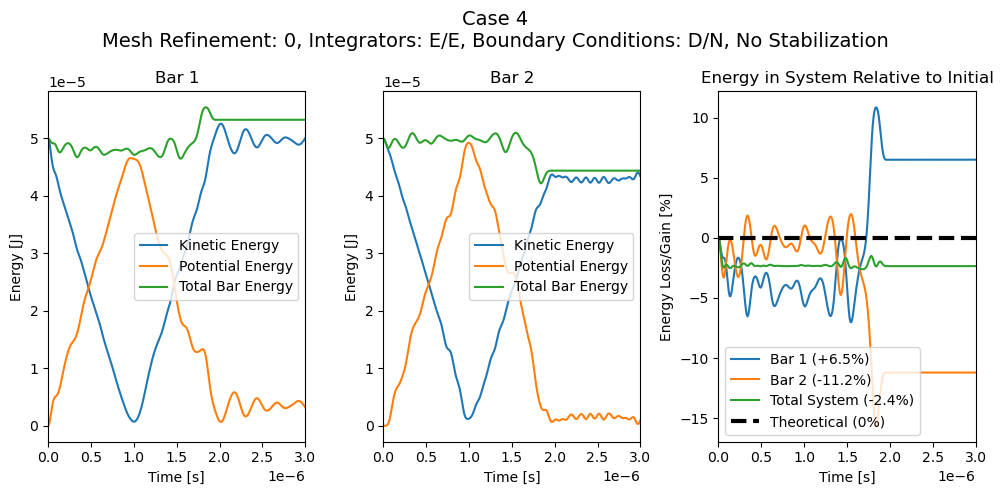

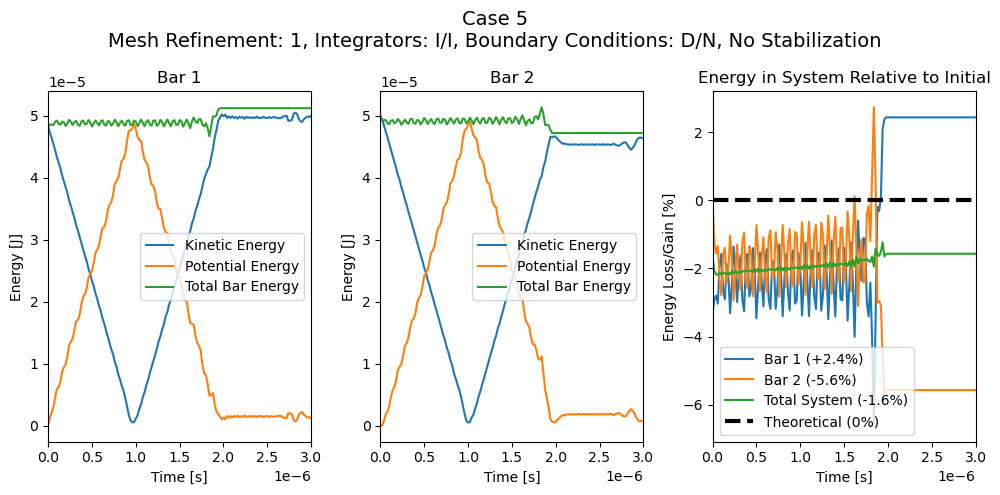

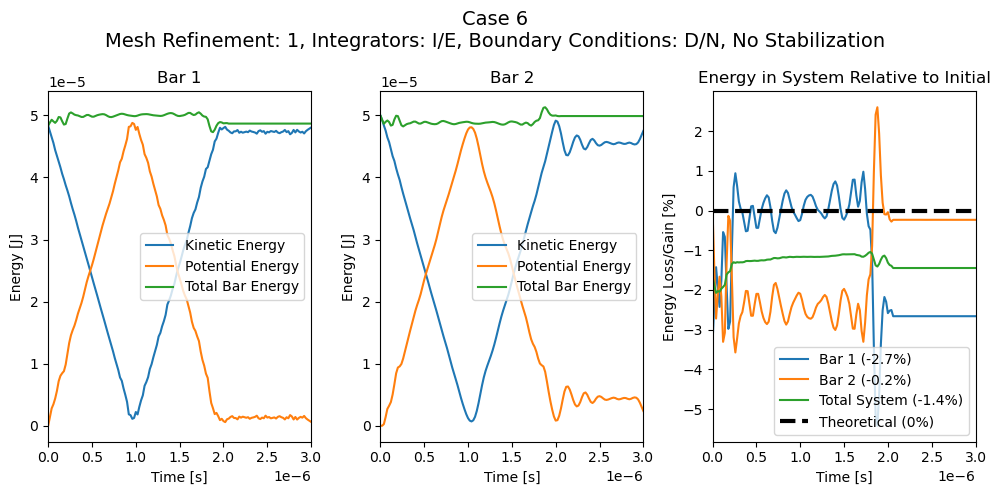

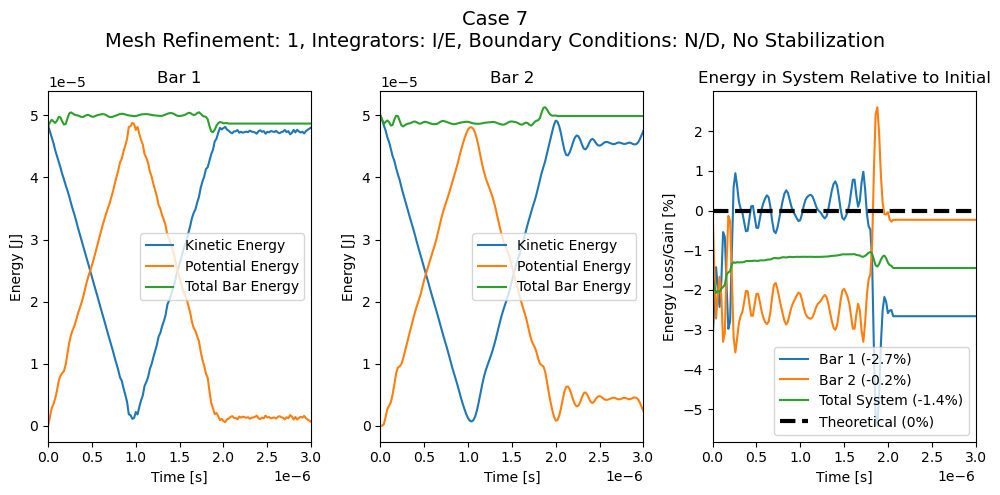

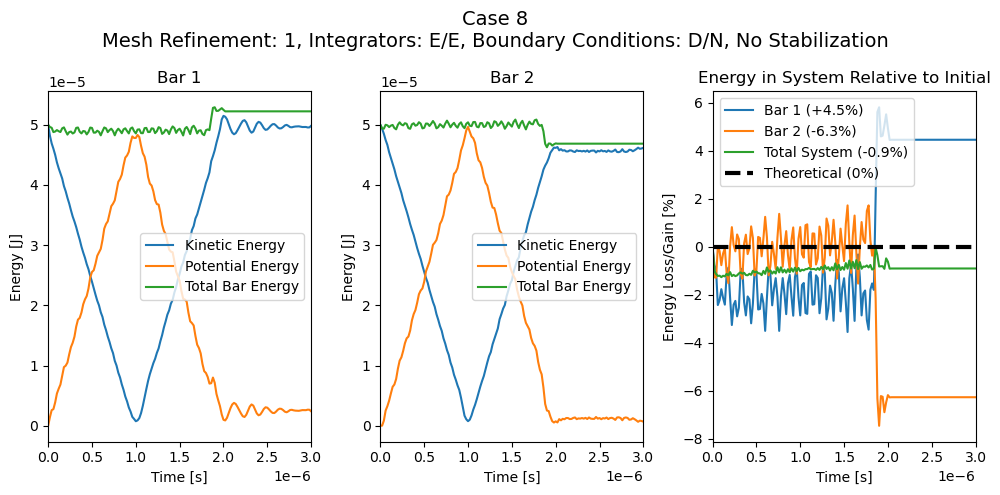

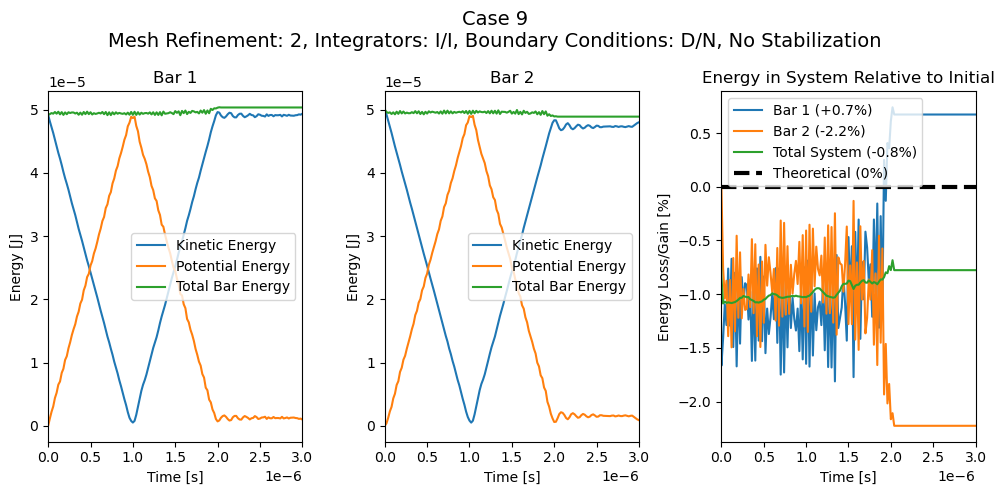

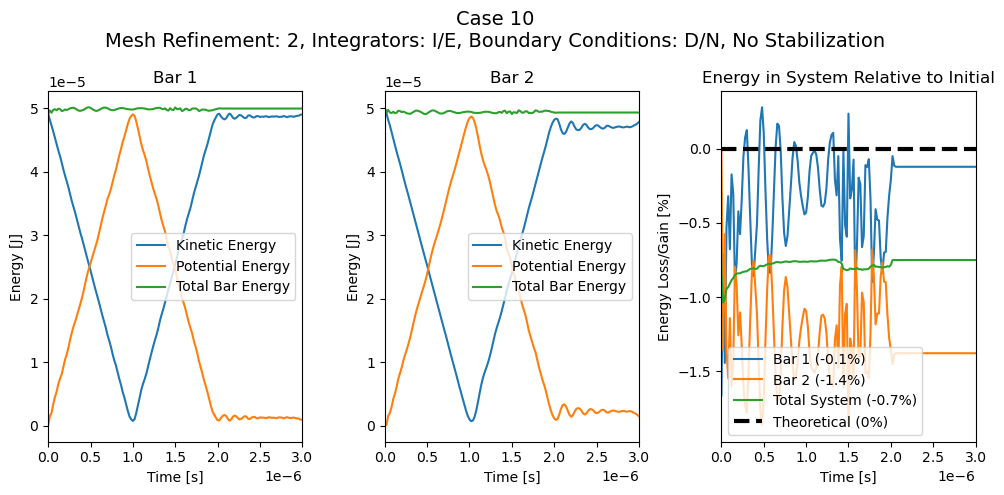

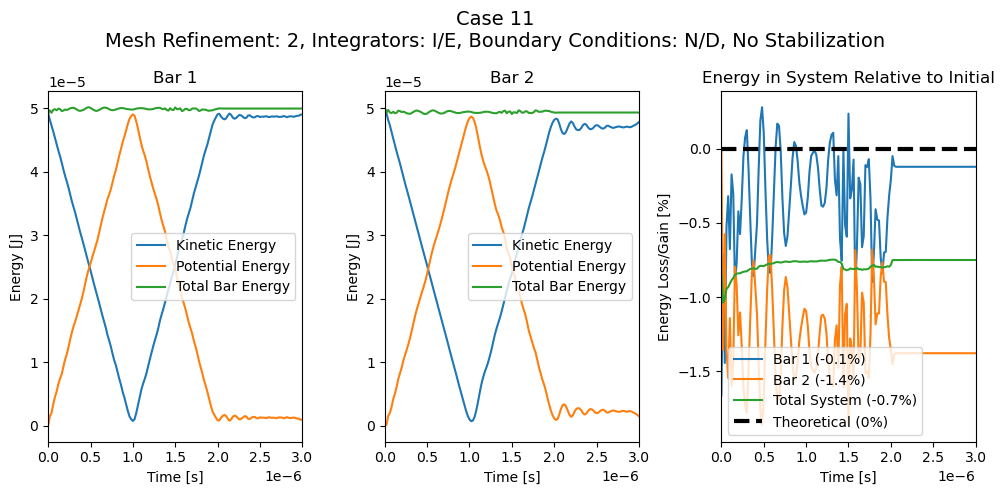

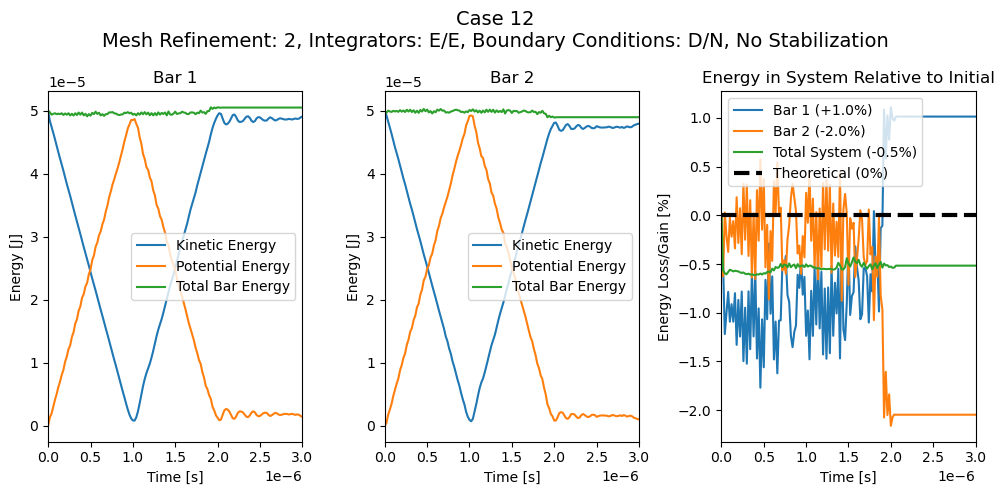

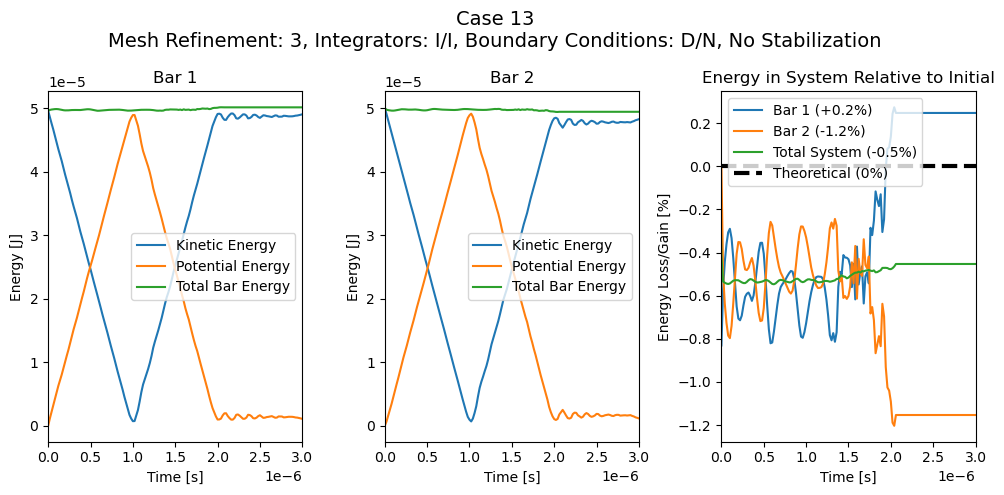

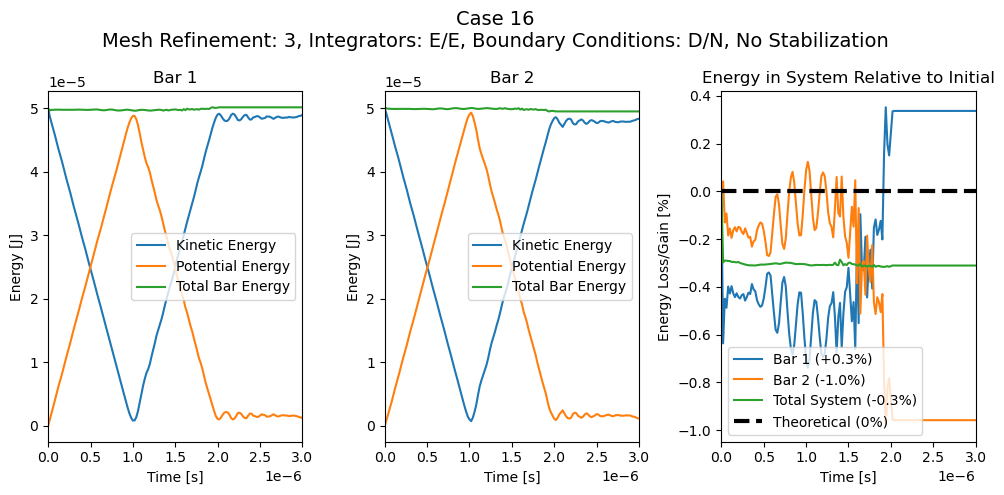

In [ ]:
for i in range(0,16):
    if case_list[i] is None:
        continue
    fig, (ax1, ax2, ax3) = plt.subplots(1,3, sharex=True)
    
    fig.set_size_inches(10,5)
    mesh_refinement = case_list[i].refinement
    integ = case_list[i].integrator_combo
    bcs = case_list[i].bc_combo
    fig.suptitle(f"Case {i+1}\nMesh Refinement: {mesh_refinement}, Integrators: {integ}, Boundary Conditions: {bcs}, No Stabilization", fontsize=14)
    ax1.plot(case_list[i].simulation_times[0], case_list[i].bar_kinetic[0], label="Kinetic Energy")
    ax1.plot(case_list[i].simulation_times[0], case_list[i].bar_potential[0], label="Potential Energy")
    ax1.plot(case_list[i].simulation_times[0], case_list[i].total_energy[0], label="Total Bar Energy")
    ax1.set_title('Bar 1')
    ax1.set_xlabel('Time [s]')
    ax1.set_ylabel('Energy [J]')
    ax1.set_xlim([0, 3.0e-06])
    ax1.legend()

    ax2.plot(case_list[i].simulation_times[1], case_list[i].bar_kinetic[1], label="Kinetic Energy")
    ax2.plot(case_list[i].simulation_times[1], case_list[i].bar_potential[1], label="Potential Energy")
    ax2.plot(case_list[i].simulation_times[1], case_list[i].total_energy[1], label="Total Bar Energy")
    ax2.set_title('Bar 2')
    ax2.set_xlabel('Time [s]')
    ax2.set_ylabel('Energy [J]')
    ax2.sharey(ax1)
    ax2.legend()

    system_energy = np.array(case_list[i].total_energy[0]) + np.array(case_list[i].total_energy[1])
    initial_energy = case_list[i].total_energy[0][0] + case_list[i].total_energy[1][0]
    analytical_initial_energy_for_a_single_bar = 0.5*(1000.0*1.0e-04*1.0e-04*1.0e-03)*100**2

    bar1_differential = case_list[i].total_energy[0]/analytical_initial_energy_for_a_single_bar*100 - 100
    bar2_differential = case_list[i].total_energy[1]/analytical_initial_energy_for_a_single_bar*100 - 100
    system_differential = system_energy/(2*analytical_initial_energy_for_a_single_bar)*100 - 100
    b1_lab = f'+{bar1_differential[-1]:.1f}%' if bar1_differential[-1] > 0 else f'{bar1_differential[-1]:.1f}%'
    b2_lab = f'+{bar2_differential[-1]:.1f}%' if bar2_differential[-1] > 0 else f'{bar2_differential[-1]:.1f}%'
    total_lab = f'+{system_differential[-1]:.1f}%' if system_differential[-1] > 0 else f'{system_differential[-1]:.1f}%'
    ax3.plot(case_list[i].simulation_times[0], bar1_differential, label=f"Bar 1 ({b1_lab})")
    ax3.plot(case_list[i].simulation_times[1], bar2_differential, label=f"Bar 2 ({b2_lab})")
    ax3.plot(case_list[i].simulation_times[1], system_differential, label=f"Total System ({total_lab})")

    ax3.plot([0, 3e-6], [0,0], 'k--', label=f"Theoretical (0%)", linewidth=3)
    ax3.set_title('Energy in System Relative to Initial')
    ax3.set_xlabel('Time [s]')
    ax3.set_ylabel('Energy Loss/Gain [%]')
    ax3.legend()

    fig.tight_layout()
    fig.savefig(f'ns_case_results_{i+1}.png')


